# Cuaderno 06 Herramientas apra bioinforamtica

## 1. Competencias
### Competencias del curso
Conoce, comprende y aplica los conceptos fundamentales de la Bioinformatica

### Competencia del laboratorio
Comparar las implementaciones desarrolladas en clase con herramientas bioinformaticas estandar usadas en investigacion y analisis reales.

## 2. Equipos y Maeriales
- Un computador.
- Lenguaje de programacion

# Importaciones

## Parametros de puntuacion

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import os
from dataclasses import dataclass, field


@dataclass
class ScoreParams:
    """Parámetros del sistema de puntuación para el alineamiento."""
    match:    int = 2
    mismatch: int = -1
    gap:      int = -2

    def score(self, a: str, b: str) -> int:
        """Retorna match o mismatch según si las bases son iguales."""
        return self.match if a.upper() == b.upper() else self.mismatch


# Parámetros del laboratorio
params = ScoreParams(match=2, mismatch=-1, gap=-2)

print("Parámetros del laboratorio:")
print(f"  Match    : +{params.match}")
print(f"  Mismatch :  {params.mismatch}")
print(f"  Gap      :  {params.gap}")


Parámetros del laboratorio:
  Match    : +2
  Mismatch :  -1
  Gap      :  -2


## Estructura de resultados alineamiento global y local

In [2]:
@dataclass
class AlignmentResult:
    """Encapsula el resultado de un alineamiento."""
    seq1_aligned: str
    seq2_aligned: str
    score:        int
    matrix:       np.ndarray
    algorithm:    str

    @property
    def identity(self) -> float:
        """Porcentaje de posiciones con match sobre el total alineado."""
        matches = sum(
            a == b
            for a, b in zip(self.seq1_aligned, self.seq2_aligned)
            if a != '-' and b != '-'
        )
        length = max(len(self.seq1_aligned), len(self.seq2_aligned))
        return matches / length * 100 if length > 0 else 0.0

    def print_alignment(self, line_width: int = 60):
        """Imprime el alineamiento en bloques formateados y alineados."""
        s1  = self.seq1_aligned
        s2  = self.seq2_aligned
        mid = ''
        for a, b in zip(s1, s2):
            if   a == '-' or b == '-': mid += ' '
            elif a.upper() == b.upper(): mid += '|'
            else:                        mid += '.'

        total = len(s1)
        print(f"  Algoritmo  : {self.algorithm}")
        print(f"  Score      : {self.score}")
        print(f"  Identidad  : {self.identity:.1f}%")
        print(f"  Longitud   : {total} nt")
        print()
        pos = 0
        while pos < total:
            chunk = slice(pos, pos + line_width)
            label_pos = pos + 1
            print(f"  Seq1 {label_pos:>5}  {s1[chunk]}")
            print(f"              {mid[chunk]}")
            print(f"  Seq2 {label_pos:>5}  {s2[chunk]}")
            print()
            pos += line_width

    def __repr__(self):
        return (f"AlignmentResult(algorithm={self.algorithm!r}, "
                f"score={self.score}, identity={self.identity:.1f}%)")


## Implemantacion Smith-Waterman

In [3]:
##
class SmithWaterman:
    """
    Alineamiento local — Smith-Waterman (1981).

    Complejidad: O(n x m) en tiempo y espacio.
    Clave: H[i][j] = max(..., 0) y traceback desde max(H) hasta H=0.
    """

    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params

    def align(self, seq1: str, seq2: str) -> AlignmentResult:
        n, m = len(seq1), len(seq2)
        H    = np.zeros((n + 1, m + 1), dtype=int)

        # Llenado de la matriz
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                diagonal  = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                arriba    = H[i-1][j]   + self.params.gap
                izquierda = H[i][j-1]   + self.params.gap
                H[i][j]   = max(0, diagonal, arriba, izquierda)

        # Traceback desde el valor máximo hasta 0
        i, j   = map(int, np.unravel_index(np.argmax(H), H.shape))
        score  = int(H[i][j])
        aln1, aln2 = '', ''

        while i > 0 and j > 0 and H[i][j] > 0:
            if H[i][j] == H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1]):
                aln1 = seq1[i-1] + aln1
                aln2 = seq2[j-1] + aln2
                i -= 1; j -= 1
            elif H[i][j] == H[i-1][j] + self.params.gap:
                aln1 = seq1[i-1] + aln1
                aln2 = '-'       + aln2
                i -= 1
            else:
                aln1 = '-'       + aln1
                aln2 = seq2[j-1] + aln2
                j -= 1

        return AlignmentResult(aln1, aln2, score, H, "Smith-Waterman")


print("SmithWaterman implementado correctamente.")


SmithWaterman implementado correctamente.


## Implementacion Needleman-Wunsch

In [4]:
class NeedlemanWunsch:
    """
    Alineamiento global — Needleman-Wunsch (1970).

    Complejidad: O(n x m) en tiempo y espacio.
    Diferencia con SW: inicializa bordes con gaps y traceback desde (n, m).
    """

    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params

    def align(self, seq1: str, seq2: str) -> AlignmentResult:
        n, m = len(seq1), len(seq2)
        H    = np.zeros((n + 1, m + 1), dtype=int)

        # Inicialización con penalización de gap en bordes
        for i in range(n + 1): H[i][0] = i * self.params.gap
        for j in range(m + 1): H[0][j] = j * self.params.gap

        # Llenado de la matriz
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                diagonal  = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                arriba    = H[i-1][j]   + self.params.gap
                izquierda = H[i][j-1]   + self.params.gap
                H[i][j]   = max(diagonal, arriba, izquierda)

        # Traceback desde la esquina (n, m)
        aln1, aln2 = '', ''
        i, j = n, m
        while i > 0 or j > 0:
            if i > 0 and j > 0 and (
                H[i][j] == H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
            ):
                aln1 = seq1[i-1] + aln1
                aln2 = seq2[j-1] + aln2
                i -= 1; j -= 1
            elif i > 0 and H[i][j] == H[i-1][j] + self.params.gap:
                aln1 = seq1[i-1] + aln1
                aln2 = '-'       + aln2
                i -= 1
            else:
                aln1 = '-'       + aln1
                aln2 = seq2[j-1] + aln2
                j -= 1

        return AlignmentResult(aln1, aln2, int(H[n][m]), H, "Needleman-Wunsch")


print("NeedlemanWunsch implementado correctamente.")


NeedlemanWunsch implementado correctamente.


## Descarga de archivos de secuencias

Descarga de secuencias desde NCBI usando Biopython Entrez. Para esto, necesitamos un email válido (requerido por NCBI) y opcionalmente una API key para aumentar el límite de solicitudes. La función `fetch_fasta_from_ncbi` nos permite obtener la secuencia en formato FASTA, así como su ID y descripción, y también guardar el archivo localmente si se desea.

1. Descargar secuencias biológicas desde bases de datos como NCBI utilizando Biopython.
2. Leer secuencias desde archivos FASTA para su posterior análisis.

In [5]:
from Bio import Entrez, SeqIO
import os
from typing import Tuple, Optional

# Configuramos tnuestro email (NCBI exige un email valido)
# Entrez.email = "miemail@example.com"
# Si tenemos api_key (opcional), usamos: Entrez.api_key = "TU_API_KEY"

def fetch_fasta_from_ncbi(accession: str, email: str, save_path: Optional[str] = None, db: str = "nucleotide") -> Tuple[str, str, str]:
    """
    Descargamso un registro FASTA desde NCBI usando Biopython Entrez y nos devuelve (id, descripcion, secuencia).
    Si proporcioanmos save_path , guardamos el archivo FASTA en esa ruta
    Parametros:
      - accession: ID o accesión (por ejemplo 'NM_000518.5' o 'U14680.1')
      - email: el email es obligatorio para usar Entrez (NCBI)
      - save_path: si no usamos None, se guarda el archivo FASTA en la ruta uqe ponemos
      - db: 'nucleotide' o 'protein' según corresponda
    Retorna:
      (record.id, record.description, str(record.seq))
    """
    Entrez.email = email
    handle = None
    try:
        handle = Entrez.efetch(db=db, id=accession, rettype="fasta", retmode="text")
        # Parseamos con SeqIO para devolver valores consistentes
        record = SeqIO.read(handle, "fasta")
        seq_id = record.id
        desc = record.description
        seq = str(record.seq)
    finally:
        if handle is not None:
            handle.close()

    if save_path:
        # Nos aseguramos de que el directorio existe
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        # Escribimos el archio FASTA (usando SeqIO para formateo correcto)
        with open(save_path, "w") as outfh:
            SeqIO.write(record, outfh, "fasta")

    return seq_id, desc, seq

In [6]:
#Leer fasta
def leer_fasta(filepath: str) -> tuple[str, str, str]:
    """Leemos un archivo FASTA y nos devuelve el ID, la descripción y la secuencia
    Argumentos:
        filepath (str): Es la ruta al archivo FASTA

    Retorna:
        tuple[str, str, str]: ID, descripción y secuencia
    """
    with open(filepath, 'r') as file:
        lineas = file.readlines()
    header = lineas[0].strip()
    #print("header: ",header)
    #print("header.split(): ",header.split())
    secuencia_id = header.split()[0][1:]  # Eliminar el '>' y obtener el ID
    descripcion = ' '.join(header.split()[1:])  # Obtener la descripción
    secuencia = ''.join(linea.strip() for linea in lineas[1:]).upper()  # Unir las líneas de la secuencia
    return secuencia_id, descripcion, secuencia

## Clase Secuencia para encapsular datos de secuencias biológicas

In [7]:
from dataclasses import dataclass
from concurrent.futures import ThreadPoolExecutor

#Dataclass nos genera automaticamente nuestro constructor
# Crea constrcutor -> __init__(),
# Genera automaticamente la impresion de datos para desarroladores -> __repr()__
# Podemos sobrecargar apra personalizar repr
#print prioriza str a repr, por eso si queremos personalizar la impresión para usuarios finales, sobrecargamos __str__() y si queremos personalizar la impresión para desarrolladores (debugging), sobrecargamos __repr__()
# property se usa como atributo no como metodo
@dataclass
class Secuencia:
    id: str
    descripcion: str
    secuencia: str

    @property
    def longitud(self) -> int:
        return len(self.secuencia)

    def __str__(self) -> str:
        """Sobrecargamos __str__ para usuarios finales (cuando hacemos print())"""
        return (f" Secuencia: {self.id}\n"
                f" Longitud: {self.longitud} pb\n"
                f" Descripción: {self.descripcion[:70]}...\n"
                f" Primeros 40 pb: {self.secuencia[:40]}...")

    def __repr__(self) -> str:
        """Sobrecargamos __repr__ para desarrolladores (debugging en consola)"""
        muestra_seq = self.secuencia[:60] + "..." if len(self.secuencia) > 60 else self.secuencia
        return (f"Secuencia(id='{self.id}', longitud={self.longitud}, "
                f"desc='{self.descripcion[:50]}...', seq='{muestra_seq}')")

## Descarfa de secuencias desde NCBI utilizando Biopython

In [8]:
#Lista de accsession
# NM_000518.5, NM_009764
lista_accession = ["NM_000518.5", "NM_009764.3", "NC_000913.2", "NC_003197.2"]

#Ejemplo de uso de la función fetch_fasta_from_ncbi
path = "data/"
email = "rhyi888@gmail.com"  # Reemplazamos con nuestro email
for accession in lista_accession:
    save_path = path + accession + ".fasta"  # Guardamos cada secuencia con su accession como nombre de archivo
    seq_id, desc, seq = fetch_fasta_from_ncbi(accession=accession, email=email, save_path=save_path)
    # Descargamos la secuencia y la guardamos en un archivo FASTA
    print(f"Accession: {accession}")
    print(f"ID: {seq_id}")
    print(f"Descripción: {desc}")
    print(f"Secuencia: {seq[:50]}...")  # Imprimimos solo los primeros 50 caracteres de la secuencia para evitar saturar la salida

Accession: NM_000518.5
ID: NM_000518.5
Descripción: NM_000518.5 Homo sapiens hemoglobin subunit beta (HBB), mRNA
Secuencia: ACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACC...
Accession: NM_009764.3
ID: NM_009764.3
Descripción: NM_009764.3 Mus musculus breast cancer 1, early onset (Brca1), mRNA
Secuencia: GTTCCGAAAGGCTAGCGCTAGGCGCCAAGCGGCCGGTTTCCTTGGCGACG...
Accession: NC_000913.2
ID: NC_000913.2
Descripción: NC_000913.2 Escherichia coli str. K-12 substr. MG1655, complete genome
Secuencia: AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAA...
Accession: NC_003197.2
ID: NC_003197.2
Descripción: NC_003197.2 Salmonella enterica subsp. enterica serovar Typhimurium str. LT2, complete genome
Secuencia: AGAGATTACGTCTGGTTGCAAGAGATCATGACAGGGGGAATTGGTTGAAA...


## Lectura de secuencias desde archivos FASTA

In [9]:
#Lista de secuencias
nombres_secuencias = ["ejemplo_labo", "NM_000518.5", "NM_009764.3","NC_000913.2", "NC_003197.2"]  # "NC_000913.2", "NC_003197.2"
path = 'data/'

# Diccionario para almacenar objetos Secuencia
# Clave: nombre del archivo (sin .fasta)
# Valor: objeto Secuencia correspondiente
secuencias = {}

for nombre in nombres_secuencias:
    filepath = path + nombre + ".fasta"
    secuencia_id, descripcion, secuencia = leer_fasta(filepath=filepath)

    # Creamos un objeto Secuencia con los datos leídos
    seq_obj = Secuencia(id=secuencia_id, descripcion=descripcion, secuencia=secuencia)

    # Lo guardamos en el diccionario con el nombre como clave
    secuencias[nombre] = seq_obj

    # Imprimir el objeto (muestra el __repr__ personalizado)
    print(seq_obj)
    print()  # Línea en blanco para separar

# Ahora podemos acceder facilmente a cualquier secuencia
print("Accedemos usando el diccionario")
print(f"Longitud de 'ejemplo_labo': {secuencias['ejemplo_labo'].longitud} pb")
print(f"ID de 'NM_000518.5': {secuencias['NM_000518.5'].id}")

 Secuencia: ejemplo_labo.3
 Longitud: 5 pb
 Descripción: Mus musculus breast cancer 1, early onset (Brca1), mRNA...
 Primeros 40 pb: ATGCA...

 Secuencia: NM_000518.5
 Longitud: 628 pb
 Descripción: Homo sapiens hemoglobin subunit beta (HBB), mRNA...
 Primeros 40 pb: ACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCA...

 Secuencia: NM_009764.3
 Longitud: 6648 pb
 Descripción: Mus musculus breast cancer 1, early onset (Brca1), mRNA...
 Primeros 40 pb: GTTCCGAAAGGCTAGCGCTAGGCGCCAAGCGGCCGGTTTC...

 Secuencia: NC_000913.2
 Longitud: 4639675 pb
 Descripción: Escherichia coli str. K-12 substr. MG1655, complete genome...
 Primeros 40 pb: AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTG...

 Secuencia: NC_003197.2
 Longitud: 4857450 pb
 Descripción: Salmonella enterica subsp. enterica serovar Typhimurium str. LT2, comp...
 Primeros 40 pb: AGAGATTACGTCTGGTTGCAAGAGATCATGACAGGGGGAA...

Accedemos usando el diccionario
Longitud de 'ejemplo_labo': 5 pb
ID de 'NM_000518.5': NM_000518.5


## Conteo de k-mers

In [10]:
#Funcion conteo de kmers usando diccionarios
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random


def _contar_rango_kmers(args: tuple[str, int, int, int]) -> dict[str, int]:
    """Cuenta k-mers para un rango de posiciones de inicio [inicio, fin)."""
    seq, k, inicio, fin = args
    contador = {}
    for i in range(inicio, fin):
        kmer = seq[i:i + k]
        contador[kmer] = contador.get(kmer, 0) + 1
    return contador

@dataclass
class KmerCounter:
    secuencia : Secuencia

    def contar_kmers(self, k: int, metodo: str = "diccionario") -> dict[str, int]:
        """
        Contamos la frecuencia de k-mers en la secuencia utilizando diferentes estrategias

        Argumentos:
            k (int) la longitud de los k-mers que contaremos
            metodo (str) y los metoidos sonm 'diccionario', 'sliding_window', 'paralelo'

        Returna:
            dict[str, int]: un diccionario con k-mers como claves y sus frecuencias como valores
        """
        if metodo == "diccionario":
            return self._contar_diccionario(k)
        elif metodo == "sliding_window":
            return self._contar_sliding_window(k)
        elif metodo == "paralelo":
            return self._contar_paralelo(k)
        else:
            raise ValueError(f"Método '{metodo}' no soportado. Use: diccionario, sliding_window, paralelo")

    def _contar_diccionario(self, k: int) -> dict[str, int]:
        """
        Metodo basico usando diccionario o hash
        Complejidad  O(n·k)  n es la longitud de la secuencia
        """
        kmers_frecuencia = {}
        seq = self.secuencia.secuencia
        n = self.secuencia.longitud

        for i in range(n - k + 1):
            kmer = seq[i:i+k]
            kmers_frecuencia[kmer] = kmers_frecuencia.get(kmer, 0) + 1

        return kmers_frecuencia

    def _contar_sliding_window(self, k: int) -> dict[str, int]:
        """
        Metodo con ventana deslizante optimizada, similar al anterior en Python puro
        Complejidad: O(n·k) nuestro slicing sigue siendo O(k)
        En codigo compilado cython sería msa rápido
        """
        kmers_frecuencia = {}
        seq = self.secuencia.secuencia
        n = self.secuencia.longitud

        # Versión optimizada: precomputamos hash de primera ventana
        if n >= k:
            kmer = seq[0:k]
            kmers_frecuencia[kmer] = 1

            # Deslizamos la ventana
            for i in range(1, n - k + 1):
                kmer = seq[i:i+k]
                kmers_frecuencia[kmer] = kmers_frecuencia.get(kmer, 0) + 1

        return kmers_frecuencia

    def _contar_paralelo(self, k: int, num_workers: int = 4) -> dict[str, int]:
        """
        Metodo paralelo que divide la secuencia en chunks y procesa en paralelo
        La coplejidad seria O(n·k / num_workers) + overhead
        En Jupyter/Windows puede ser mas lento por overhead de multiprocessing
        """
        seq = self.secuencia.secuencia
        n = self.secuencia.longitud
        if n < k:
            return {}
        if num_workers <= 1 or n < 2 * k:
            return self._contar_diccionario(k)

        total_inicios = n - k + 1
        chunk_size = max(1, total_inicios // num_workers)

        rangos = []
        for inicio in range(0, total_inicios, chunk_size):
            fin = min(total_inicios, inicio + chunk_size)
            rangos.append((seq, k, inicio, fin))

        try:
            with ThreadPoolExecutor(max_workers=num_workers) as executor:
                resultados = list(executor.map(_contar_rango_kmers, rangos))
        except Exception:
            # Fallback seguro para Jupyter/Windows si multiprocessing falla
            resultados = [_contar_rango_kmers(rango) for rango in rangos]

        kmers_frecuencia = {}
        for contador_parcial in resultados:
            for kmer, freq in contador_parcial.items():
                kmers_frecuencia[kmer] = kmers_frecuencia.get(kmer, 0) + freq

        return kmers_frecuencia

## 3. Actividades
1. Investigue la herramienta EMBOSS needle para el alineamiento global de secuencias y compare los resultados de procesar secuencias con la herramienta y su código elaborado (version web)

Para esto usamos primero nuestra función de alineamiento global Needleman-Wunsch implementada en clase y luego usamos la herramienta EMBOSS needle en su versión web para comparar los resultados. Para esto, ingresamos las mismas secuencias que usamos en nuestro código (por ejemplo, NM_000518.5 y NM_009764.3) y comparamos el score, la identidad y el alineamiento obtenido con nuestra implementación.

Link usado de la pagina web https://emboss.bioinformatics.nl/cgi-bin/emboss/needle?utm_source=chatgpt.com

In [11]:
seq1 = secuencias["NM_000518.5"]
seq2 = secuencias["NM_009764.3"]
sw_demo = SmithWaterman(params).align(seq1.secuencia, seq2.secuencia)

print("Secuencias de demostración:")
print(f"  Seq1: {seq1}")
print(f"  Seq2: {seq2}")
print()

print("Smith-Waterman (local):")
sw_demo.print_alignment()

Secuencias de demostración:
  Seq1:  Secuencia: NM_000518.5
 Longitud: 628 pb
 Descripción: Homo sapiens hemoglobin subunit beta (HBB), mRNA...
 Primeros 40 pb: ACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCA...
  Seq2:  Secuencia: NM_009764.3
 Longitud: 6648 pb
 Descripción: Mus musculus breast cancer 1, early onset (Brca1), mRNA...
 Primeros 40 pb: GTTCCGAAAGGCTAGCGCTAGGCGCCAAGCGGCCGGTTTC...

Smith-Waterman (local):
  Algoritmo  : Smith-Waterman
  Score      : 316
  Identidad  : 54.0%
  Longitud   : 691 nt

  Seq1     1  CATTTGCTTCTGACAC-A--ACTGTGTTCACTAGCA-ACCTCA--A-ACAGACACCATGG
              ||.|| ...|||||.| |  ||||.|...|||| || |..|.|  | |.|.||| .|||.
  Seq2     1  CACTT-TAACTGACGCAATTACTGAGGAGACTA-CACATGTAATTATAAAAACA-GATGC

  Seq1    61  TGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGG
              .|..|.||..| .||| |.|.|..||| ...|| |  ..|.| |||| | .||.|.|.||
  Seq2    61  GGAGTTTGTGT-GTGA-GCGGACACTG-AAATA-T--TTTCT-GGGC-A-TTGCAGGAGG

  Seq1   121  ATGAAGTTGGTGGTGAGGCCCTGGGC

Configuracion en la pagina web de EMBOSS needle:
- Sequence 1: NM_000518.5
- Sequence 2: NM_009764.3

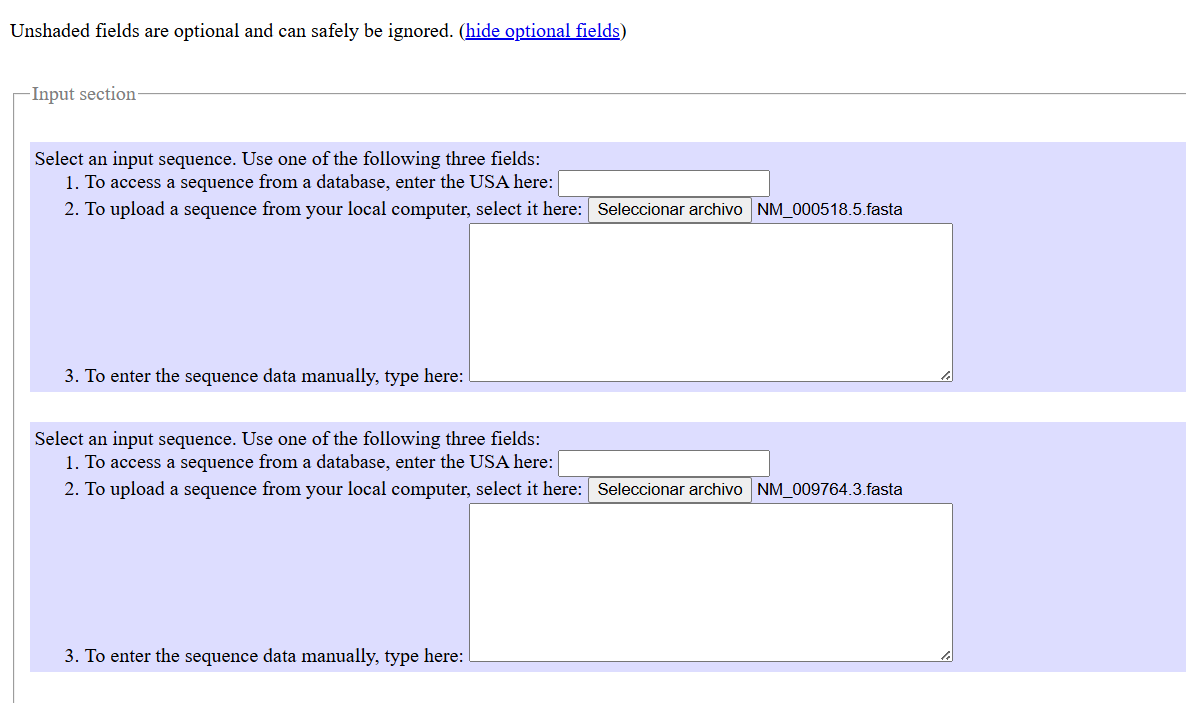
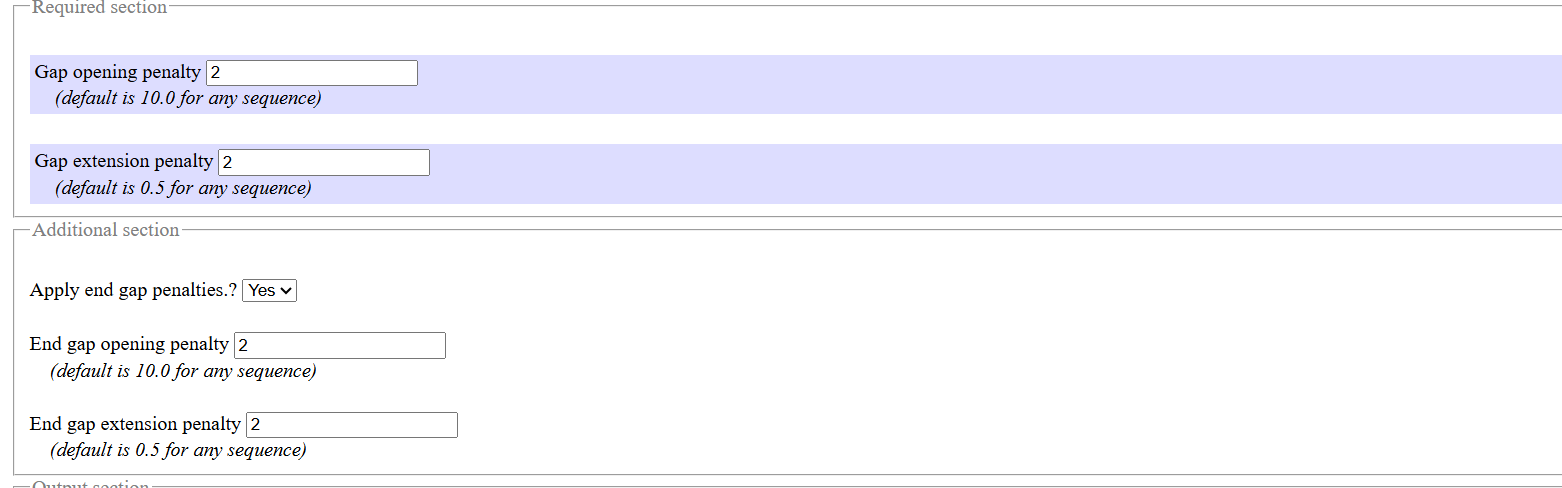
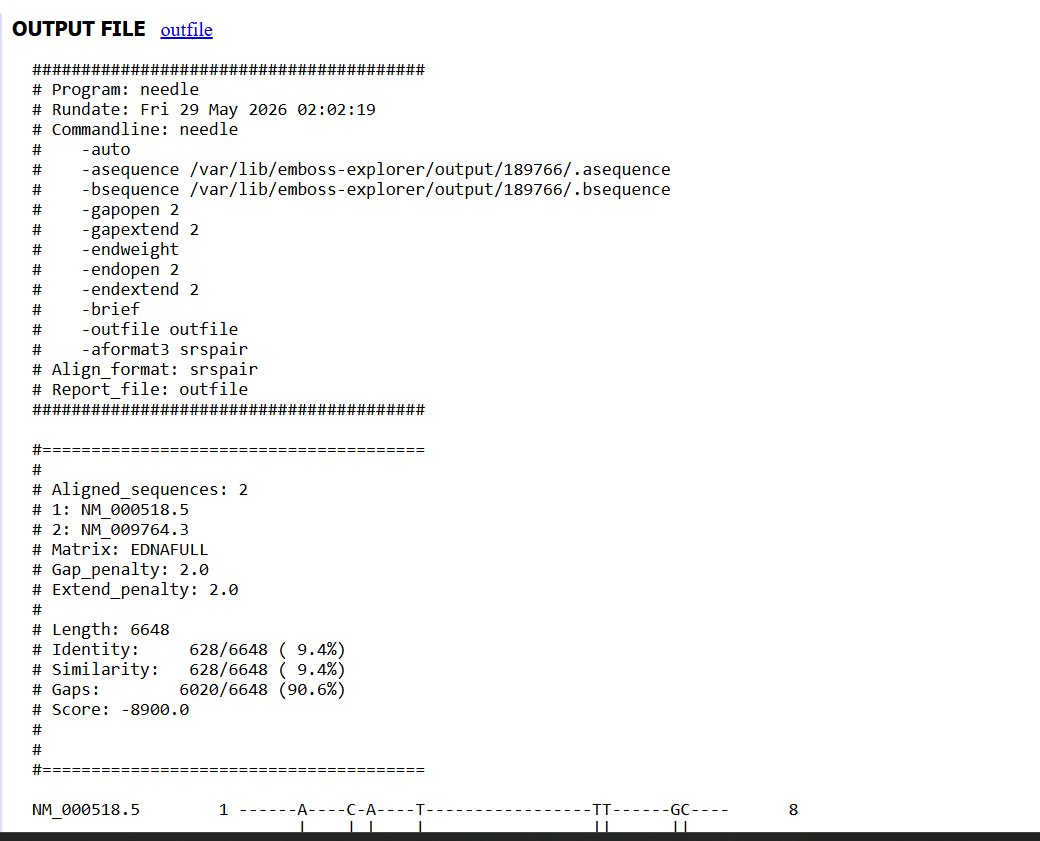
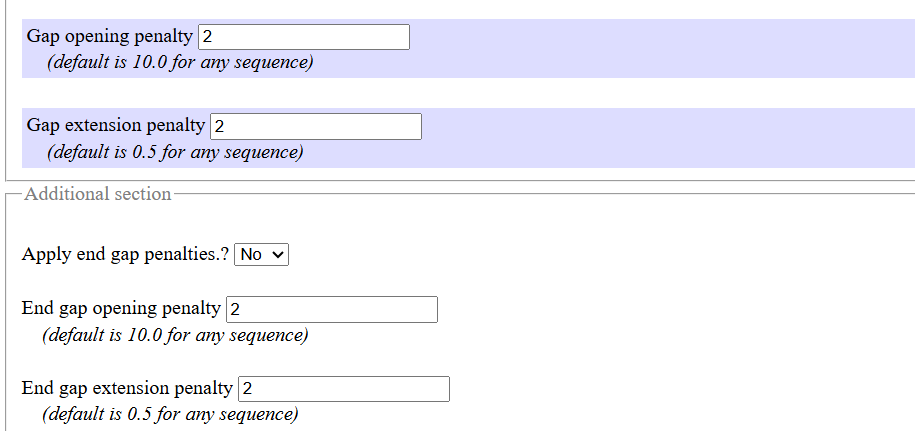
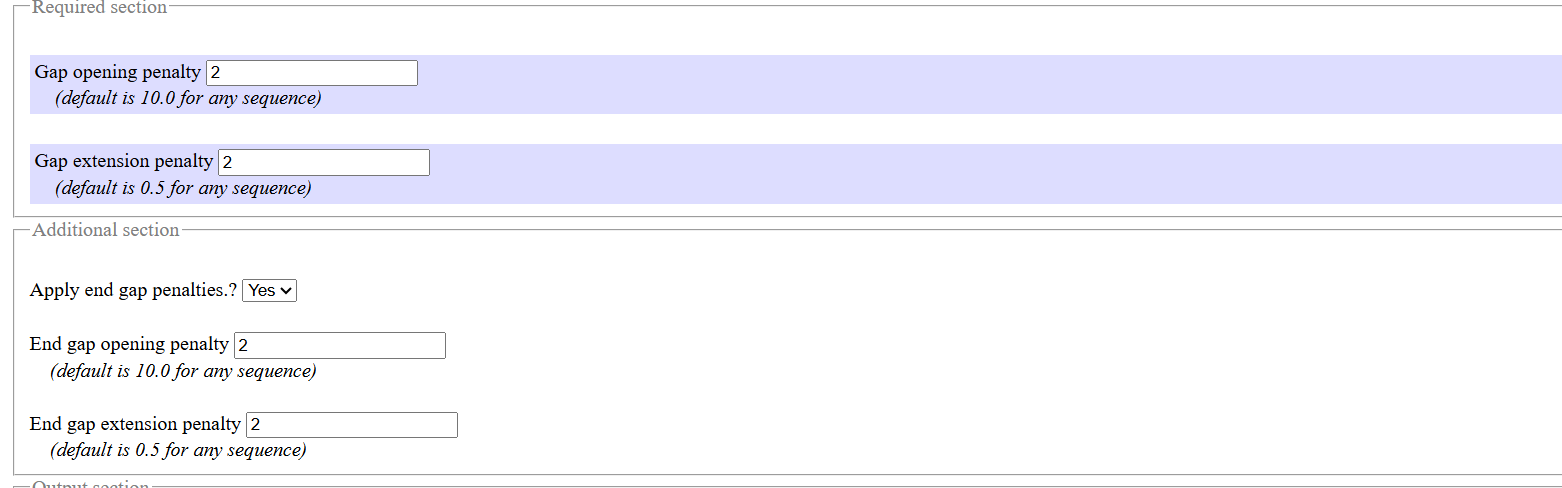

El resultado esat completo en el archivo resultados/emboss_needle.txt

2. Investigue la herramienta EMBOSS water para el alineamiento local de secuencias y compare los resultados de procesar secuencias con la herramienta y su código elaborado


Por esto usamos primero nuestra función de alineamiento local Smith-Waterman implementada en clase y luego usamos la herramienta EMBOSS water en su versión web para comparar los resultados. Para esto, ingresamos las mismas secuencias que usamos en nuestro código (por ejemplo, NM_000518.5 y NM_009764.3) y comparamos el score, la identidad y el alineamiento obtenido con nuestra implementación.


In [12]:
seq1 = secuencias["NM_000518.5"]
seq2 = secuencias["NM_009764.3"]
nw_demo = NeedlemanWunsch(params).align(seq1.secuencia, seq2.secuencia)

print("Secuencias de demostración:")
print(f"  Seq1: {seq1}")
print(f"  Seq2: {seq2}")
print()

print("Smith-Waterman (local):")
nw_demo.print_alignment()

Secuencias de demostración:
  Seq1:  Secuencia: NM_000518.5
 Longitud: 628 pb
 Descripción: Homo sapiens hemoglobin subunit beta (HBB), mRNA...
 Primeros 40 pb: ACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCA...
  Seq2:  Secuencia: NM_009764.3
 Longitud: 6648 pb
 Descripción: Mus musculus breast cancer 1, early onset (Brca1), mRNA...
 Primeros 40 pb: GTTCCGAAAGGCTAGCGCTAGGCGCCAAGCGGCCGGTTTC...

Smith-Waterman (local):
  Algoritmo  : Needleman-Wunsch
  Score      : -10784
  Identidad  : 9.4%
  Longitud   : 6648 nt

  Seq1     1  ------------------------------------------------------------
                                                                          
  Seq2     1  GTTCCGAAAGGCTAGCGCTAGGCGCCAAGCGGCCGGTTTCCTTGGCGACGGAGAGCGCGG

  Seq1    61  ------------------------------------------------------------
                                                                          
  Seq2    61  GAATTTTAGATAGATTGTAATTGCGGCTGCGCGGCCGCTGCCCGTGCAGCCAGAGGATCC

  Seq1   121  ---------------------

Para la comparacion usaremos en wsl:
```bash
sudo apt update
sudo apt install emboss
```

Y verificamos:
```bash
water -help
```

## Comandos
Entro a mi carpeta
```bash
cd "/mnt/d/TRABAJOS 2025B/GITHUB/bio-notebooks/06/data"
```

Usamos nuestras secuencias de ejemplo
```bash
water NM_000518.5.fasta NM_009764.3.fasta \
-gapopen 2 \
-gapextend 2 \
-outfile ../resultados/water_result.txt
```
El resultado esta completo en el archivo resultados/water_result.txt


3. Investigue la herramienta Jellyfish para el conteo de k-mers y compárelo los resultados de procesar secuencias con la herramienta y con su código elaborado


In [13]:
# Ejemplo con metodo diccionario (es opr defecto)
k = 3#
lista_seq = ["NM_000518.5", "NM_009764.3"]
for nombre_seq in lista_seq:
    print("==============================================")
    print("Ejemplo con k=",k," usando método diccionario:")
    seq_test = secuencias[nombre_seq]
    print(seq_test)
    counter_test = KmerCounter(secuencia=seq_test)
    kmers_test = counter_test.contar_kmers(k=3, metodo="diccionario")

    #print(seq_test)
    print(f"k-mers únicos: {len(kmers_test)}")
    print(f"\nTop 10 k-mers más frecuentes:")
    kmers_ordenados = sorted(kmers_test.items(), key=lambda x: x[1], reverse=True)
    for kmer, freq in kmers_ordenados[:10]:
        print(f"  {kmer}: {freq} veces")


Ejemplo con k= 3  usando método diccionario:
 Secuencia: NM_000518.5
 Longitud: 628 pb
 Descripción: Homo sapiens hemoglobin subunit beta (HBB), mRNA...
 Primeros 40 pb: ACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCA...
k-mers únicos: 62

Top 10 k-mers más frecuentes:
  CTG: 31 veces
  TGG: 27 veces
  GTG: 23 veces
  CCT: 21 veces
  TGC: 19 veces
  GGC: 19 veces
  GCT: 18 veces
  TGA: 16 veces
  AAG: 16 veces
  CAC: 15 veces
Ejemplo con k= 3  usando método diccionario:
 Secuencia: NM_009764.3
 Longitud: 6648 pb
 Descripción: Mus musculus breast cancer 1, early onset (Brca1), mRNA...
 Primeros 40 pb: GTTCCGAAAGGCTAGCGCTAGGCGCCAAGCGGCCGGTTTC...
k-mers únicos: 64

Top 10 k-mers más frecuentes:
  AGA: 205 veces
  AAA: 202 veces
  CAG: 202 veces
  GAA: 199 veces
  AAG: 186 veces
  GAG: 172 veces
  TGA: 171 veces
  CTG: 166 veces
  AGC: 154 veces
  GGA: 147 veces


Para la comparacion usaremos en wsl:
```bash
sudo apt update
sudo apt install jellyfish -y
```
Y verificamos:
```bash
jellyfish --version
```
## Comandos
Entro a mi carpeta
```bash
cd "/mnt/d/TRABAJOS 2025B/GITHUB/bio-notebooks/06/data"
```

Veriffcamos:
```bash
ls
```

Usamos nuestras secuencias de ejemplo
```bash
jellyfish count -m 3 -s 100M -t 4 NM_000518.5.fasta -o ../resultados/NM_000518.5.jf
jellyfish count -m 3 -s 100M -t 4 NM_009764.3.fasta -o ../resultados/NM_009764.3.jf
```

Vemos los resultados
```bash
jellyfish histo ../resultados/NM_000518.5.jf > ../resultados/NM_000518.5.histo
jellyfish histo ../resultados/NM_009764.3.jf > ../resultados/NM_009764.3.histo
```

Y finalmente podemos ver el conteo de k-mers
```bash
jellyfish dump ../resultados/NM_000518.5.jf > ../resultados/NM_000518.5_kmers.txt
jellyfish dump ../resultados/NM_009764.3.jf > ../resultados/NM_009764.3_kmers.txt
```

Convertimos el dump a TSV "kmer<tab>frecuencia" para facilitar la lectura
```bash
awk 'NR%2==1 {c=substr($0,2); getline; print $0 "\t" c}' ../resultados/NM_000518.5_kmers.txt > ../resultados/NM_000518.5_kmers.tsv
awk 'NR%2==1 {c=substr($0,2); getline; print $0 "\t" c}' ../resultados/NM_009764.3_kmers.txt > ../resultados/NM_009764.3_kmers.tsv
```

Vemos  las primeras lineas del TSV para verificar
```bash
head -n 20 ../resultados/NM_000518.5_kmers.tsv
# Salida ejemplo: CTG    31
head -n 20 ../resultados/NM_009764.3_kmers.tsv
# Salida ejemplo: AGA    205
```

La salida es:
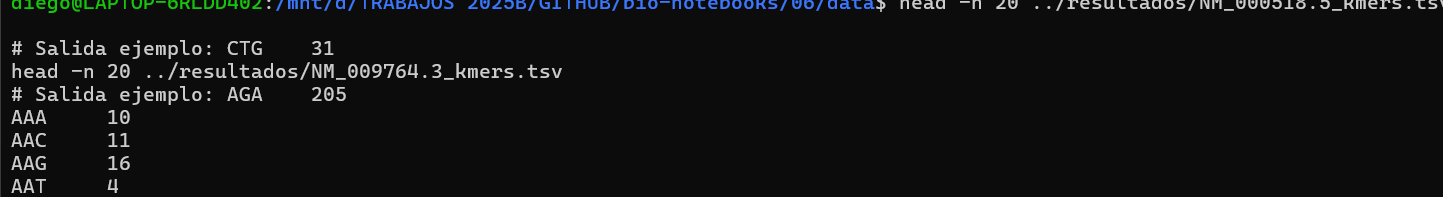


Obtenemos los 10 k-mers mas frecuentes de cada secuencia para comparar con nuestro código

```bash
sort -k2 -nr ../resultados/NM_000518.5_kmers.tsv | head -n 10
sort -k2 -nr ../resultados/NM_009764.3_kmers.tsv | head -n 10
```

La salida es:
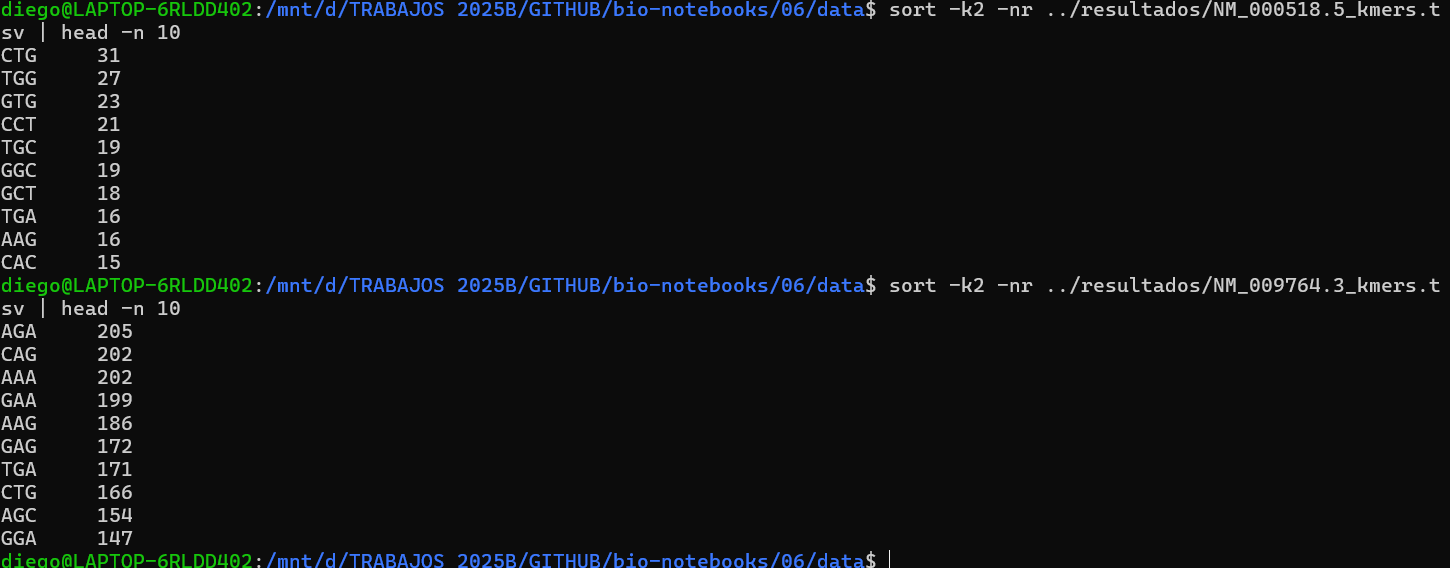

4. Analizar las diferencias entre las herramientas y los algoritmos desarrollados

En el laboratorio se trabajó con implementaciones propias de algoritmos bioinformáticos y también con herramientas especializadas como EMBOSS y Jellyfish. Esto permitió comparar tanto los resultados obtenidos como el comportamiento y rendimiento de cada enfoque.

## Comparación entre Needle/Water y la implementación propia

La implementación propia de los algoritmos de alineamiento permitió comprender el funcionamiento interno de:

- Needleman-Wunsch (alineamiento global)
- Smith-Waterman (alineamiento local)

Durante el desarrollo se implementaron manualmente:

- La matriz de puntuaciones
- Penalizaciones por gaps
- Match y mismatch
- Traceback
- Reconstrucción del alineamiento

Por otro lado, las herramientas de EMBOSS ya contienen implementaciones altamente optimizadas y validadas científicamente.

### Diferencias observadas

| Aspecto | Implementación propia | EMBOSS |
|---|---:|---|
| Objetivo | Educativo | Profesional |
| Velocidad | Menor | Mucho más rápida |
| Facilidad de uso | Requiere programación | Uso directo mediante comandos |
| Control interno | Alto | Bajo |
| Escalabilidad | Limitada | Alta |
| Precisión | Correcta para pruebas | Optimizada y validada |

En el alineamiento global con Needleman-Wunsch se observó que las secuencias tenían longitudes muy diferentes, produciendo una gran cantidad de gaps y una similitud baja. En cambio, el alineamiento local con Smith-Waterman encontró regiones conservadas más relevantes biológicamente, obteniendo un score mucho mejor.

Esto permitió entender que:

- El alineamiento global intenta alinear toda la secuencia.
- El alineamiento local busca únicamente las regiones más similares.

## Comparación entre Jellyfish y el algoritmo propio de k-mers

La implementación propia de conteo de k-mers permitió comprender:

- Cómo recorrer secuencias biológicas
- Cómo generar substrings de tamaño k
- Cómo almacenar frecuencias
- Cómo analizar patrones repetidos

Mientras tanto, Jellyfish está diseñado específicamente para procesamiento masivo de secuencias.

### Diferencias observadas

| Aspecto | Implementación propia | Jellyfish |
|---|---:|---|
| Complejidad | Simple y educativa | Optimizada |
| Rendimiento | Menor | Muy alto |
| Uso de memoria | Básico | Eficiente |
| Paralelización | No implementada / limitada | Multihilo |
| Facilidad de depuración | Alta | Baja |
| Escalabilidad | Limitada | Muy alta |

Se observó que Jellyfish procesó las secuencias rápidamente incluso usando múltiples hilos (-t 4), mientras que la implementación propia es más adecuada para comprender la lógica del algoritmo.

Además, los resultados que botuvimos fueron consistentes entre ambas implementaciones, lo cual valida el funcionamiento correcto del código desarrollado.

## Conclusiones generales

Las implementaciones propias fueron fundamentales para comprender la lógica interna de los algoritmos bioinformáticos y el manejo de secuencias biológicas.

Sin embargo, herramientas especializadas como EMBOSS y Jellyfish ofrecen:

- Mejor rendimiento
- Mayor optimización
- Soporte para datasets grandes
- Resultados más robustos
- Escalabilidad profesional

Por ello, en entornos reales de bioinformática utilizamos herramientas optimizadas, mientras que las implementaciones propias son especialmente útiles para aprendizaje, investigación y validación de conceptos.

